# 1. Importar todas las librerías necesarias


In [12]:
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn


# 2. Inicializar algunas variables que después modificaremos

In [13]:
dataset = []
hostnames = []
df = None

# 3. Crear una función para generar los hostnames en base a unas reglas

In [14]:
def set_hostnames(number_of_hosts: int) -> None:
  distribucion_os = ["L"]*40 + ["S"]*30 + ["A"]*20 + ["H"]*10
  distribucion_environment = ["D"]*10 + ["I"]*10 + ["T"]*25 + ["S"]*25 + ["P"]*30
  distribucion_country = ["NOR"]*6 + ["FRA"]*9 + ["ITA"]*16 + ["ESP"]*16 + ["DEU"]*23 + ["IRL"]*30
  grupo_hostname = []

  for i in range(number_of_hosts):
    hostname = random.choice(distribucion_os) + random.choice(distribucion_environment) + random.choice(distribucion_country)
    grupo_hostname.append(hostname)
    hostname += str(grupo_hostname.count(hostname)).zfill(3)
    hostnames.append(hostname)


# 4. Crear una función obtener el nombre del SO

In [15]:
def get_os(hostname: str) -> str:
  if hostname.startswith("L"):
    return "Linux"
  elif hostname.startswith("S"):
    return "Solaris"
  elif hostname.startswith("A"):
    return "AIX"
  elif hostname.startswith("H"):
    return "HP-AUX"
  else:
    return "Unknown"

# 5. Crear una función para obtener el nombre del entorno

In [16]:
def get_environment(hostname: str) -> str:
    environment = hostname[1]

    if environment == "D":
        return "Development"
    elif environment == "I":
        return "Integration"
    elif environment == "T":
        return "Test"
    elif environment == "S":
        return "Staging"
    elif environment == "P":
        return "Production"
    else:
        return "Unknown"

# 6. Crear una función para obtener el nombre del país

In [17]:
def get_country(hostname: str) -> str:
    country = hostname[2:5]

    if country == "NOR":
        return "Norway"
    elif country == "FRA":
        return "France"
    elif country == "ITA":
        return "Italy"
    elif country == "ESP":
        return "Spain"
    elif country == "DEU":
        return "Germany"
    elif country == "IRL":
        return "Ireland"
    else:
        return "Unknown"

# 7. Crear una función para generar el DataFrame

In [18]:
def set_dataframe(count: int) -> None:
  global df

  set_hostnames(count)

  for codigo in hostnames:
    dataset.append({
        "codigo_hostname": codigo,
        "os": get_os(codigo),
        "environment": get_environment(codigo),
        "country": get_country(codigo),
        "count": int(codigo[-3:])
    })

  df = pd.DataFrame(dataset)

# 8. Crear el DataFrame

In [19]:

set_dataframe(1500)
df

,codigo_hostname,os,environment,country,count
0,SSIRL001,Solaris,Staging,Ireland,1
1,HDIRL001,HP-AUX,Development,Ireland,1
2,STIRL001,Solaris,Test,Ireland,1
3,LPITA001,Linux,Production,Italy,1
4,LTDEU001,Linux,Test,Germany,1
...,...,...,...,...,...
1495,HSITA004,HP-AUX,Staging,Italy,4
1496,LTDEU037,Linux,Test,Germany,37
1497,LPESP020,Linux,Production,Spain,20
1498,LIIRL017,Linux,Integration,Ireland,17


# 9. Guardar el DataFrame generado en un fichero CSV



In [20]:
df.to_csv(
    "hostnames.csv",
    header = True,
    index = False
)

df_hostnames = pd.read_csv("hostnames.csv")
df_hostnames

,codigo_hostname,os,environment,country,count
0,SSIRL001,Solaris,Staging,Ireland,1
1,HDIRL001,HP-AUX,Development,Ireland,1
2,STIRL001,Solaris,Test,Ireland,1
3,LPITA001,Linux,Production,Italy,1
4,LTDEU001,Linux,Test,Germany,1
...,...,...,...,...,...
1495,HSITA004,HP-AUX,Staging,Italy,4
1496,LTDEU037,Linux,Test,Germany,37
1497,LPESP020,Linux,Production,Spain,20
1498,LIIRL017,Linux,Integration,Ireland,17


# 10. Generar un único gráfico, agrupando para cada país los entornos

<Axes: xlabel='country'>

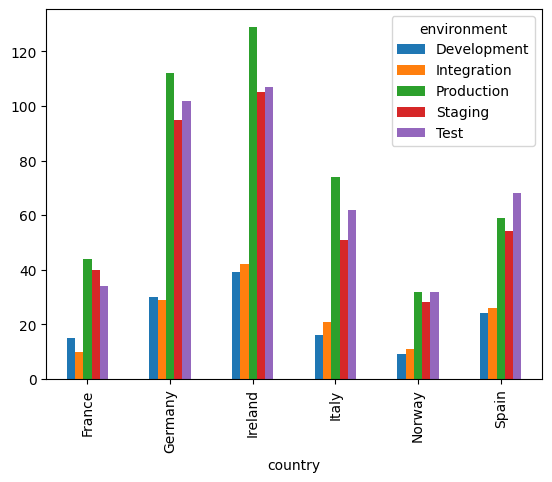

In [21]:
g = df.groupby(["country", "environment"]).size()
g.unstack().plot(kind="bar")

# 11. Crear una figura con 4 gráficos en una malla de 2 filas y 2 columnas


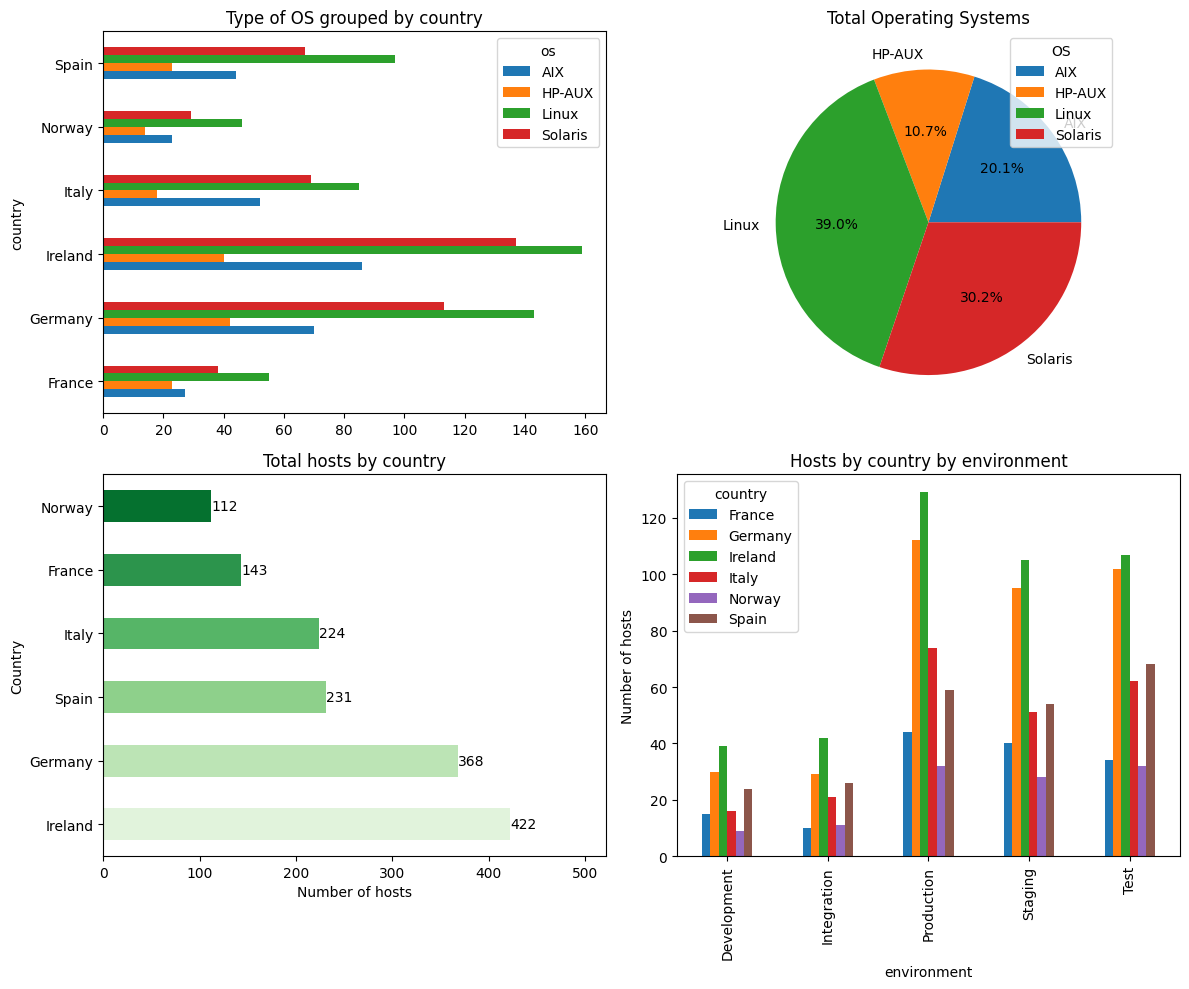

In [22]:
fig, axs = plt.subplots(2, 2, figsize=(12,10))

#grafico 1

os_country = df.groupby(["country", "os"]).size()
ax = axs[0,0]
os_country.unstack().plot(kind="barh", ax=ax)
axs[0,0].set_title("Type of OS grouped by country")

#gráfico 2

total_os = df.groupby("os").size()
axs[0,1].pie(
    total_os.values,
    labels=total_os.index,
    autopct="%1.1f%%"
)
axs[0,1].set_title('Total Operating Systems')
axs[0,1].legend(title="OS", loc="upper right")


#gráfico 3

hosts_country = df["country"].value_counts()
ax = axs[1,0]
hosts_country.plot(
    kind="barh",
    ax=ax,
    color=seaborn.color_palette("Greens", len(hosts_country))
)

ax.bar_label(ax.containers[0])
axs[1,0].set_title("Total hosts by country")
axs[1,0].set_xlabel("Number of hosts")
axs[1,0].set_ylabel("Country")
axs[1,0].set_title("Total hosts by country")
axs[1,0].set_xlim(0, max(hosts_country)+100)

#gráfico 4

hosts = df.groupby(["country","environment"]).size()
ax = axs[1,1]
hosts.unstack(0).plot(kind="bar", ax=ax)
axs[1,1].set_ylabel("Number of hosts")
axs[1,1].set_title("Hosts by country by environment")

fig.tight_layout()

